In [ ]:
# Authors: Jen Epstein, Rebecca Orrison, Ashok Sankaran, Christopher Cane
# Date created: August 22, 2025
# The purpose of this notebook is to provide the necessary analysis for blog 1 of the PHMSA pipeline enforcement project for EDGI
# Data: "Enforcement Cases Initiated from 2002 (data as of 03/04/2026)" : https://primis.phmsa.dot.gov/enforcement-data/

# Instructions: Run the first two cells: 
# 1: Contains all necessary formatting and libraries throughout. Proceed from there to any particular section of the workflow. 
# 2: Contains consistent data to use throughout the analysis
%pip install seaborn
%pip install matplotlib
%pip install pandas
%pip install pyfonts
%pip install scipy

In [1]:
# ------------------------------
# 1: RUN FOR UNIVERSAL SETTINGS
# ------------------------------

# Load libraries
import pandas as pd
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import calendar
from datetime import date
import os
from pyfonts import load_google_font

# COLOR SETTINGS
# ------------------------------

# Gradients, see Design Approach tab in our project Google doc.
unicolor_darkblue_gradient = [
    [0.0, "#EEEBE6"],
    [0.5, "#19649F"],
    [1.0, "#092439"],
]

unicolor_orange_gradient = [
    [0.0, "#EEEBE6"],
    [0.5, "#DBBE48"],
    [1.0, "#C97C08"],
]

bicolor_standard_gradient = [
    [0.0, "#19659e"],
    [0.5, "#dbbe48"],
    [1.0, "#A74956"],
]

bicolor_whitemiddle_gradient = [
    [0.0, "#19659e"],
    [0.5, "#F9F7F4"],
    [1.0, "#C97C08"],
]

# Simple list versions of the gradients, which we can use for seaborn color palettes:
bicolor_standard_list = ["#19659e", "#dbbe48", "#A74956"]

# For matplotlib, need to create a cmap object from the gradients defined above:
def create_matplotlib_cmap(name, gradient_list):
    tupled_list = list(tuple(x) for x in gradient_list)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name, tupled_list)
    return cmap

# palettes for plots
core_palette = ['#092439','#19649F','#F9F7F4','#EEEBE6','#E0DCD5','#746F68']
additional_colors = ['#53ADA4','#DBBE48','#C97C08','#70A8D2','#A74956']

# Make discrete colormap for "crest"
crest_disc = sns.color_palette("crest", 5)

unicolor_darkblue_cmap = create_matplotlib_cmap("unicolor_darkblue", unicolor_darkblue_gradient)
unicolor_orange_cmap = create_matplotlib_cmap("unicolor_orange", unicolor_orange_gradient)
bicolor_standard_cmap = create_matplotlib_cmap("bicolor_standard", bicolor_standard_gradient)
bicolor_whitemiddle_cmap = create_matplotlib_cmap("bicolor_whitemiddle", bicolor_whitemiddle_gradient)

# Helper function to create a color palette of n colors from a given cmap, which we can use with matplotlib:
def create_color_palette(cmap, num_colors, start=0.2, end=1):
    """Create a color palette from a given colormap.

    Args:
        cmap (LinearSegmentedColormap): The colormap from which to create the palette.
        num_colors (int): The number of colors to include in the palette.
        start (float, optional): The starting point for the color interpolation. Defaults to 0.2.
        end (float, optional): The ending point for the color interpolation. Defaults to 1.

    Returns:
        ListedColormap: A colormap containing the specified number of colors.
    """    
    return cmap.resampled(num_colors)(np.linspace(start, end, num_colors))

# Set formatting options

pd.options.mode.copy_on_write = True
sns.set_theme(style="whitegrid", palette=bicolor_standard_list)

# FONT SETTINGS
# ------------------------------

# Get Mona Sans font from Google Fonts. 
# URL: https://fonts.google.com/specimen/Mona+Sans
font_path_regular = load_google_font("Mona Sans", weight='regular')
font_path_bold = load_google_font("Mona Sans", weight='bold')
matplotlib.font_manager.fontManager.addfont(font_path_regular.get_file())
matplotlib.font_manager.fontManager.addfont(font_path_bold.get_file())

# Helper function to set matplotlib fonts to our chosen font. This needs to be called AFTER sns.set_theme() is called,
# hence this helper function to make that quick every time we graph something.
def set_matplotlib_font(style = "regular"):
    plt.rcParams["font.family"] = 'sans-serif'
    if style == "regular":
        plt.rcParams["font.sans-serif"] = font_path_regular.get_name()
        sns.set_context("notebook", rc={"font.family": font_path_regular.get_name()})
    elif style == "bold":
        plt.rcParams["font.sans-serif"] = font_path_bold.get_name()
        sns.set_context("notebook", rc={"font.family": font_path_bold.get_name()})

set_matplotlib_font("regular")

# Helper function for saving images nicely - note - not all images use this. 
def save_plt_as_image(plt_title):
    # Remove unsafe filename characters
    safe_title = "".join(c for c in plt_title if c.isalnum() or c in " _-")
    output_path = os.path.join(output_dir, safe_title + ".png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved '{safe_title}' image to: {output_path}")

# Set up image export to save figs into github.
output_dir = os.path.join("phmsa_enforcement_analysis", "Images")
# Create Images folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# Looking at palettes: 
sns.palplot(core_palette)
sns.palplot(additional_colors)
sns.palplot(bicolor_standard_list)
sns.palplot(crest_disc[::-1])

In [3]:
# ------------------------------
# 2: RUN FOR UNIVERSAL DATA
# ------------------------------
# Import data
file = os.path.join("phmsa_enforcement_analysis", "Data", "PHMSA Pipeline Enforcement Raw Data.txt")

data = pd.read_csv(file,
    sep="\t",
    encoding="latin1"
)

# convert date to a datetime object and create a column with the year value
data['Opened_Date'] = pd.to_datetime(data['Opened_Date'], errors="coerce")
data["Year"] = data['Opened_Date'].dt.year
data["Month"] = data["Opened_Date"].dt.month


<positron-console-cell-3>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


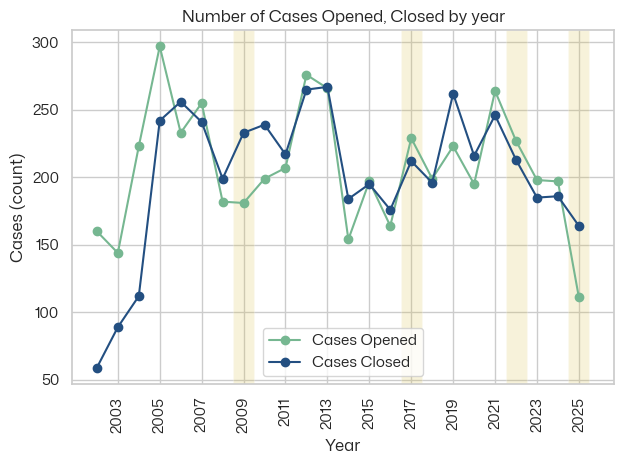

In [4]:
# ------------------------------
# FIG 1: ALL CASES OPEN/CLOSED BY YEAR
# ------------------------------
 
# Sort data by year: only keep data through 2025 to keep a full year of data
case_opened = data.groupby('Opened_Year').size()
case_closed = data.groupby('Closed_Year').size()

dat_cases = {'Opened Year': case_opened.iloc[:-1],
            'Closed Year': case_closed.iloc[:-1]}

df_cases = pd.DataFrame(data=dat_cases, index = np.arange(2002, 2026))

# Plotting
# Simple plotting...  
fig, ax = plt.subplots()

# highlight first year of each administration in the background
ax.axvspan(2008.5, 2009.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1])
ax.axvspan(2016.5, 2017.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1])
ax.axvspan(2021.5, 2022.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1])
ax.axvspan(2024.5, 2025.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1])

ax.plot(df_cases.index, df_cases['Opened Year'], c=crest_disc[0], marker='o', label='Cases Opened')
ax.plot(df_cases.index, df_cases['Closed Year'], c=crest_disc[4], marker='o', label='Cases Closed')

# Make pretty
plt.title('Number of Cases Opened, Closed by year')
ax.set_xlabel('Year')
ax.set_xticks(np.arange(2003,2026,2))
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Cases (count)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.tight_layout()

path = os.path.join(output_dir, 'open_closed_2002_2025.png')
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

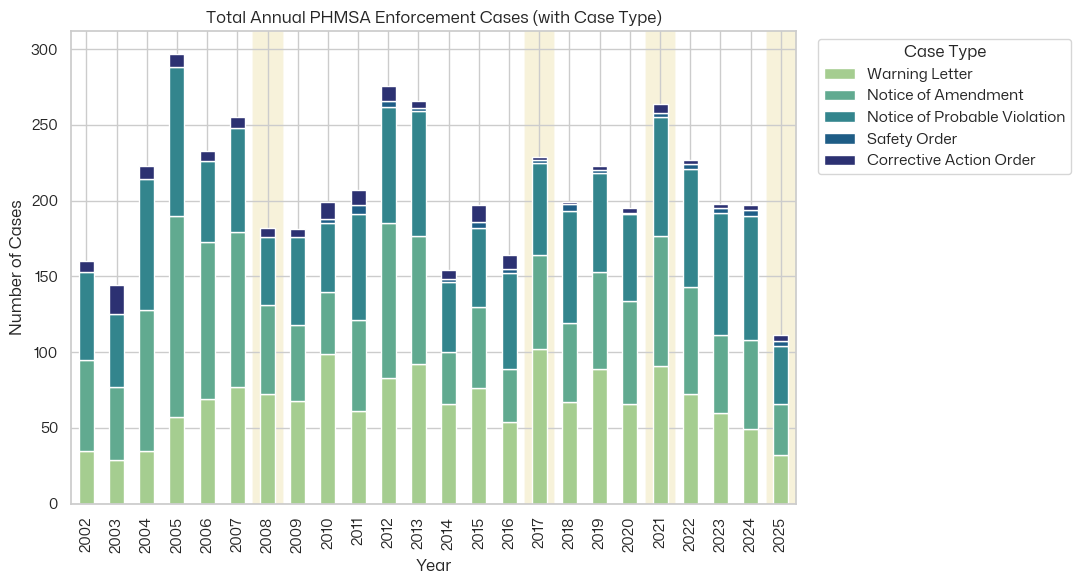

In [5]:
# ------------------------------
# FIG #2: CASES PER YEAR BY CASE TYPE
# ------------------------------

#Count for 2002 -- 2025
case_counts = (
    data[data['Year']<2026]
    .groupby(["Year", "Case_Type"])
    .size()
    .reset_index(name="Count")
)

# Pivot to stacked format
stacked = (
    case_counts
    .pivot(index="Year", columns="Case_Type", values="Count")
    .fillna(0)
)

# # Order case types by total count (highest first)
# order = (
#     stacked.sum(axis=0)
#     .sort_values(ascending=False)
#     .index
# )

# # Reorder columns
# stacked_ordered = stacked[order]

# Order case types by escalating 'severity'
stacked_caseorder = stacked[['Warning Letter', 'Notice of Amendment', 'Notice of Probable Violation', 'Safety Order', 'Corrective Action Order']]

# Plotting

ax = stacked_caseorder.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="crest"
)

plt.title("Total Annual PHMSA Enforcement Cases (with Case Type)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend(title="Case Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# highlight first year of each administration
ax.axvspan(5.5, 6.5, facecolor= bicolor_standard_list[1], alpha=0.2, zorder=0)  
ax.axvspan(14.5, 15.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=0)
ax.axvspan(18.5, 19.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=0)
ax.axvspan(22.5, 23.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=0)

plt.tight_layout()

plt.show()

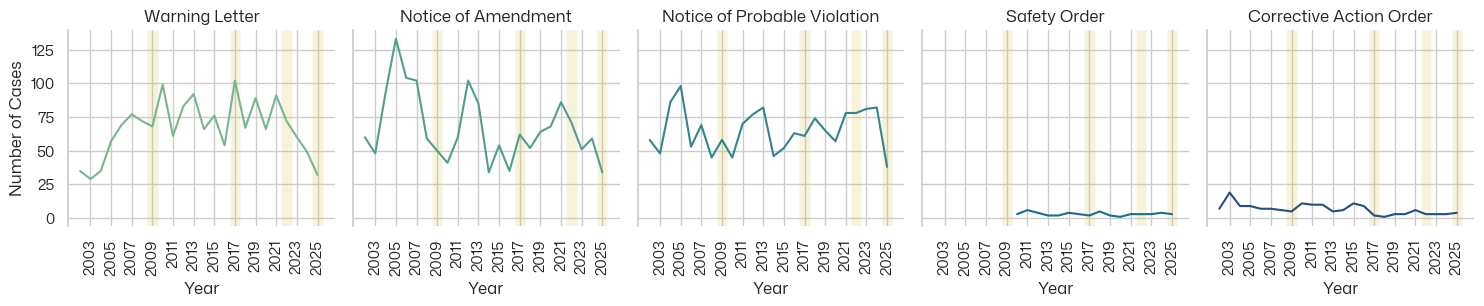

In [10]:
# ------------------------------
# FIG #3: CASE TYPES OVER TIME
# ------------------------------
 
# summarize penalty data by year and case type
penalties_case_type = data[['Year','CPF_Number','Case_Type','Proposed_Penalties','Assessed_Penalties', 'Collected_Penalties']].groupby(['Year','Case_Type']).sum()[['Proposed_Penalties', 'Assessed_Penalties','Collected_Penalties']]
penalties_case_type['num_cases'] = data.groupby(['Year','Case_Type']).count().rename(columns={'CPF_Number':'num_cases'})['num_cases']
penalties_case_type = penalties_case_type.reset_index()
# define the case type as a categorical sequence for plots
penalties_case_type['Case_Type'] = penalties_case_type['Case_Type'].astype('category')
penalties_case_type_25 = penalties_case_type[penalties_case_type['Year'] < 2026]

# define the sequence of violation types
violations_sequence = ['Warning Letter','Notice of Amendment','Notice of Probable Violation','Safety Order','Corrective Action Order']

# plot case types over time
# COLORS NOT WORKING CORRECTLY! 
g = sns.FacetGrid(penalties_case_type_25, 
                  col='Case_Type', 
                  col_order=violations_sequence, 
                  hue='Case_Type', 
                  hue_order=violations_sequence,
                  palette=crest_disc)
g = g.map(sns.lineplot, 
          'Year', 
          'num_cases').despine(bottom=True)
for i in range(0,5):
    g.axes[0,i].set_title(violations_sequence[i])
    g.axes[0,i].set_xlabel('Year')
    g.axes[0,i].tick_params('x', labelrotation=90)
    g.axes[0,i].set_xticks(np.arange(2003,2026,2))
    # Set vertical bars: 
    # highlight first year of each administration in the background
    g.axes[0,i].axvspan(2008.5, 2009.5, facecolor= bicolor_standard_list[1], alpha=0.2)
    g.axes[0,i].axvspan(2016.5, 2017.5, facecolor= bicolor_standard_list[1], alpha=0.2)
    g.axes[0,i].axvspan(2021.5, 2022.5, facecolor= bicolor_standard_list[1], alpha=0.2)
    g.axes[0,i].axvspan(2024.5, 2025.5, facecolor= bicolor_standard_list[1], alpha=0.2)

g.axes[0,0].set_ylabel('Number of Cases')

# save the figure
path = os.path.join(output_dir, "case_types_time.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Regression analysis of the above figures. 
# Numbers of Corrective Action Order, Notice of Probable Violations, and Warning Letters increased from 2002-2005. From 2005-2024 (note, not including 2025), Notice of Amendments look to be in a long-term decline. 
for type in violations_sequence:
    c_type = penalties_case_type_25[penalties_case_type_25['Case_Type'] == type] 
    c_type_24 = c_type[c_type['Year'] < 2025]
    # Plotting case type
    plt.plot(c_type['Year'], c_type['num_cases'], label = 'Case Type: '+ type)

    # Plot regression excluding 2025
    slope, intercept, r, p, se = linregress(c_type_24['Year'], c_type_24['num_cases'])
    plt.plot(c_type_24['Year'], slope*c_type_24['Year'] + intercept, label = 'r squared =  '+ str('{0:.{1}f}'.format(r**2,2))+'\np value = ' + str('{0:.{1}f}'.format(p,2)))
    
    # Plot regression with 2025
    slope, intercept, r, p, se = linregress(c_type['Year'], c_type['num_cases'])
    plt.plot(c_type['Year'], slope*c_type['Year'] + intercept, label = 'r squared =  '+ str('{0:.{1}f}'.format(r**2,2))+'\np value = ' + str('{0:.{1}f}'.format(p,2)))

    # Add legend:
    plt.legend()
    plt.show()

In [ ]:
# Regression analysis of the above figures. 
# Numbers of Notice of Amendments, Notice of Probable Violations, and Warning Letters increased from 2002-2005. From 2005-2024 (note, not including 2025), Notice of Amendments look to be in a long-term decline. 

noa = penalties_case_type_25[penalties_case_type_25['Case_Type'] == 'Notice of Amendment'] 
noa_24 = noa[noa['Year'] < 2025]
# Plotting NoA
plt.plot(noa['Year'], noa['num_cases'], label = 'Case Type: Notice of Amendment')

# Plot regression excluding 2025
slope, intercept, r, p, se = linregress(noa_24['Year'], noa_24['num_cases'])
plt.plot(noa_24['Year'], slope*noa_24['Year'] + intercept, label = 'r squared =  '+ str('{0:.{1}f}'.format(r**2,2))+'\np value = ' + str('{0:.{1}f}'.format(p,2)))
# print('2002 -- 2024: r squared = ' + str(r**2))
# print('2002 -- 2024: p value = ' + '{0:.{1}f}'.format(p,2))

# Plot regression with 2025
slope, intercept, r, p, se = linregress(noa['Year'], noa['num_cases'])
plt.plot(noa['Year'], slope*noa['Year'] + intercept, label = 'r squared =  '+ str('{0:.{1}f}'.format(r**2,2))+'\np value = ' + str('{0:.{1}f}'.format(p,2)))

# print('2002 -- 2025: r squared = ' + str(r**2))
# print('2002 -- 2025: p value = ' + '{0:.{1}f}'.format(p,2))

# Add legend:
plt.legend()

In [11]:
penalties_nopv['proposed_per_case']

2       30326.724138
6       21354.166667
10      26055.813953
14      46509.693878
18      62864.150943
22      60330.434783
26     195857.777778
30     111531.034483
34     100840.000000
39      52434.285714
44     113855.844156
49     119212.195122
54      58069.565217
59      59126.923077
64     134300.000000
69      47437.704918
74      95378.378378
79      59421.538462
84      69309.140351
89     135888.243590
94     148717.730769
99     155309.629630
104     62583.439024
109    368325.105263
114    105561.714286
Name: proposed_per_case, dtype: float64

<positron-console-cell-7>:35: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.


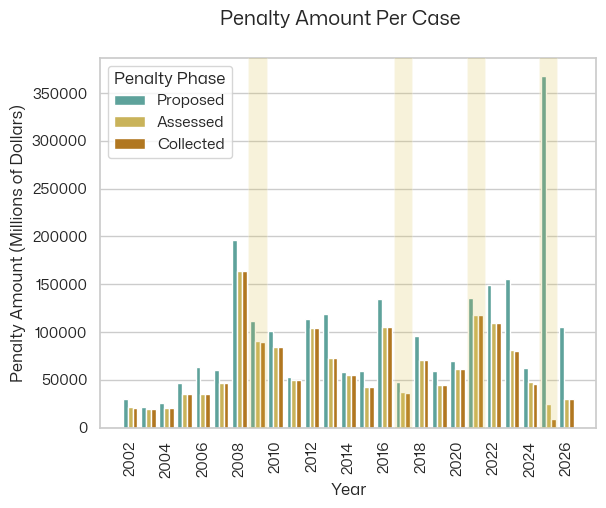

In [ ]:
# ------------------------------
# FIG #4: AVERAGE NOPV PENALTIES OVER TIME
# ------------------------------

# we see that notices of probable violation are the only case type with a penalty associated
# penalties_case_type.loc[penalties_case_type['Proposed_Penalties'] > 0.0]['Case_Type'].unique()

# create df of Notices of Probable Violation cases only
penalties_nopv = penalties_case_type[penalties_case_type['Case_Type'] == 'Notice of Probable Violation']
# calculate average penalty amounts --- BY NUMBER OF NOPVs
penalties_nopv['proposed_per_case'] = penalties_nopv['Proposed_Penalties'] / penalties_nopv['num_cases']
penalties_nopv['assessed_per_case'] = penalties_nopv['Assessed_Penalties'] / penalties_nopv['num_cases']
penalties_nopv['collected_per_case'] = penalties_nopv['Collected_Penalties'] / penalties_nopv['num_cases']
# penalties_nopv.head()

# stack the data for plotting
penalties_nopv_stack_avg = penalties_nopv.rename(columns={'proposed_per_case':'Proposed',
                                                          'assessed_per_case':'Assessed',
                                                          'collected_per_case':'Collected'
                                                         }
                                                ).set_index('Year').drop(['Case_Type',
                                                                          'num_cases',
                                                                          'Proposed_Penalties',
                                                                          'Assessed_Penalties',
                                                                          'Collected_Penalties'
                                                                         ],axis=1)
penalties_nopv_stack_avg.columns.name = 'penalty_type'
penalties_nopv_stack_avg = penalties_nopv_stack_avg.stack()
penalties_nopv_stack_avg.name = 'amount'
penalties_nopv_stack_avg = penalties_nopv_stack_avg.reset_index()
# penalties_nopv_stack_avg

# Plotting
fig, ax = plt.subplots()
ax = sns.barplot(penalties_nopv_stack_avg, 
                 x = 'Year', 
                 y = 'amount',
                 hue = 'penalty_type',
                 palette=additional_colors)

fig.suptitle('Penalty Amount Per Case')
ax.set_ylabel('Penalty Amount (Millions of Dollars)')
ax.set_xlabel('Year')
ax.tick_params('x', labelrotation=90)#, direction='out') #direction keyword not working
ax.set_xticks(ax.get_xticks()[::2])
ax.set_xticklabels(labels = np.arange(2003,2025,2))

plt.legend(title='Penalty Phase')

# highlight first year of each administration
ax.axvspan(22.5, 23.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=10)
ax.axvspan(18.5, 19.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=10)
ax.axvspan(14.5, 15.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=10)
ax.axvspan(6.5, 7.5, facecolor= bicolor_standard_list[1], alpha=0.2, ymin=0, ymax=ax.get_ylim()[1],zorder=10)

# save the figure
path = os.path.join(output_dir, "penalty_amt_per_case.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
#fig_name = "Total_annual penalties"
#plt.savefig(output_path + fig_name +".png", dpi=300, bbox_inches="tight")

In [ ]:
# ------------------------------
# FIG #: CASES PER YEAR WITH INSPECTION REPORTS
# ------------------------------
incident_counts = (
    data
    .groupby(["Year", "Report_Type"])
    .size()
    .reset_index(name="Count")
)

incident_counts_years = (
    incident_counts
    .pivot(index="Year", columns="Report_Type", values="Count")
    .fillna(0)
)

incident_counts_years.plot(
    kind="bar",
    figsize=(11, 6),
    colormap="crest"
)

plt.title("Total Annual PHMSA Enforcement Cases with Incident Reports")
plt.xlabel("Year")
plt.ylabel("Number of Cases with Incident Reports")
plt.legend(title="Incident Reports", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_plt_as_image(plt.gca().get_title())

plt.show()


# ------------------------------
# Plot groupings related to Biden vs. Trump admin periods
# From phmsa_enforcement_analysis.py
# ------------------------------

In [ ]:
# Setup and helper functions for rest of the graphs. Always run this first.
# ------------------------------
# DEFINE ADMIN PERIODS
# ------------------------------
# latest_date is dependent on latest available data.
latest_date = data["Opened_Date"].max()
trump_start = pd.Timestamp("2025-01-20")
biden_start = pd.Timestamp("2021-01-20")
current_inauguration = pd.Timestamp("2025-01-20")
start_period = current_inauguration.to_period("M")
end_period = latest_date.to_period("M")
custom_palette = {"Biden 2021": "#1f77b4", "Trump 2025": "#d62728"}

num_months = (latest_date.year - trump_start.year) * 12 + (latest_date.month - trump_start.month) + 1

# 3. Define the end dates using the same monthly offset
# Using MonthEnd ensures we capture all data up to the end of the current reporting month
trump_end = trump_start + pd.DateOffset(months=num_months - 1) + pd.offsets.MonthEnd(0)
biden_end = biden_start + pd.DateOffset(months=num_months - 1) + pd.offsets.MonthEnd(0)

# Filter
phmsa_biden = data[(data["Opened_Date"] >= biden_start) & (data["Opened_Date"] <= biden_end)].copy()
phmsa_biden['Month'] = phmsa_biden['Month'] + (phmsa_biden['Year'] - biden_start.year) * 12
phmsa_trump = data[(data["Opened_Date"] >= trump_start) & (data["Opened_Date"] <= trump_end)].copy()
phmsa_trump['Month'] = phmsa_trump['Month'] + (phmsa_trump['Year'] - trump_start.year) * 12

phmsa_biden["Month"] = ((phmsa_biden["Opened_Date"].dt.year - biden_start.year) * 12 + 
                        (phmsa_biden["Opened_Date"].dt.month - biden_start.month) + 1)

phmsa_trump["Month"] = ((phmsa_trump["Opened_Date"].dt.year - trump_start.year) * 12 + 
                        (phmsa_trump["Opened_Date"].dt.month - trump_start.month) + 1)

# Add president labels
phmsa_biden["President"] = "Biden 2021"
phmsa_trump["President"] = "Trump 2025"

# Combine
phmsa_filtered = pd.concat([phmsa_biden, phmsa_trump], ignore_index=True)

# ------------------------------
# SETTINGS
# ------------------------------
month_range = range(1, num_months + 1)
# Create dynamic labels (e.g., "1 Jan", "2 Feb"...)
month_labels = []
for i in month_range:
    month_idx = (trump_start.month + i - 2) % 12 + 1
    month_labels.append(f"{i}\n{calendar.month_abbr[month_idx]}")

# ------------------------------
# HELPER TO FILL MISSING MONTHS
# ------------------------------
def add_missing_months(df, value_col):
    months = pd.DataFrame({"Month": month_range})
    df = months.merge(df, on="Month", how="left").fillna({value_col: 0})
    return df



In [ ]:
# ------------------------------
# CASES OPENED PER MONTH
# ------------------------------
monthly_counts = phmsa_filtered.groupby(["President", "Month"]).size().reset_index(name="Count")

# Fill missing months and plot. Remember to start at February for beginning of term. 
filled_counts = pd.concat([
    add_missing_months(monthly_counts[monthly_counts["President"]=="Biden 2021"], "Count").assign(President="Biden 2021"),
    add_missing_months(monthly_counts[monthly_counts["President"]=="Trump 2025"], "Count").assign(President="Trump 2025")
])

sns.lineplot(
    data=filled_counts,
    x="Month",
    y="Count",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Enforcement Cases Opened: First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Number of Cases Opened")
plt.xticks(month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# COLLECTED PENALTIES PER MONTH
# ------------------------------
monthly_collected = phmsa_filtered.groupby(["President", "Month"])["Collected_Penalties"].sum().reset_index()

filled_collected = pd.concat([
    add_missing_months(monthly_collected[monthly_collected["President"]=="Biden 2021"], "Collected_Penalties").assign(President="Biden 2021"),
    add_missing_months(monthly_collected[monthly_collected["President"]=="Trump 2025"], "Collected_Penalties").assign(President="Trump 2025")
])

sns.lineplot(
    data=filled_collected,
    x="Month",
    y="Collected_Penalties",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Collected Penalties: First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Total Collected Penalties ($)")
plt.xticks(month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# PENALTY COMPARISON (Proposed, Assessed, Collected)
# ------------------------------
penalties = phmsa_filtered.groupby(["President", "Month"])[["Proposed_Penalties","Assessed_Penalties","Collected_Penalties"]].sum().reset_index()

# Ensure missing months are zero
def fill_penalty_months(df, president):
    months = pd.DataFrame({"Month": month_range})
    df = months.merge(df, on="Month", how="left").fillna(0)
    df["President"] = president
    return df

biden_penalties = fill_penalty_months(penalties[penalties["President"]=="Biden 2021"], "Biden 2021")
trump_penalties = fill_penalty_months(penalties[penalties["President"]=="Trump 2025"], "Trump 2025")

penalties_long = pd.concat([biden_penalties, trump_penalties], ignore_index=True).melt(
    id_vars=["President", "Month"],
    value_vars=["Proposed_Penalties","Assessed_Penalties","Collected_Penalties"],
    var_name="Penalty_Type",
    value_name="Amount"
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, pres in zip(axes, ["Biden 2021", "Trump 2025"]):
    subset = penalties_long[penalties_long["President"]==pres]
    sns.lineplot(
        data=subset,
        x="Month",
        y="Amount",
        hue="Penalty_Type",
        marker="o",
        ax=ax,
        #clip_on=False
    )
    ax.set_title(pres)
    ax.set_xticks(month_range)
    ax.set_xticklabels(month_labels)
    ax.set_ylabel("Penalty Amount ($)")
    ax.set_ylim(0, None, auto=True)
    ax.legend(title="Penalty Type")

plt_title = "Monthly Penalties: Proposed, Assessed, Collected"
plt.suptitle(plt_title, fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# FREQUENCY OF INCIDENT REPORTS
# ------------------------------
# Filter valid reports
phmsa_valid = phmsa_filtered[phmsa_filtered["Report_Type"].notna() & (phmsa_filtered["Report_Type"] != "")]

# Group by president/year/month
monthly_cases = (
    phmsa_valid.groupby(["President", "Year", "Month"])
    .size()
    .reset_index(name="Cases")
)

# Ensure all months are represented
all_months = pd.DataFrame({"Month": month_range})
filled_cases_list = []

for president, year in [("Biden 2021", 2021), ("Trump 2025", 2025)]:
    subset = monthly_cases.query("President == @president").copy()
    subset = all_months.merge(subset, on="Month", how="left")
    subset["Cases"] = subset["Cases"].fillna(0)
    subset["President"] = president
    subset["Year"] = year
    filled_cases_list.append(subset)

filled_cases = pd.concat(filled_cases_list, ignore_index=True)

# ------------------------------
# PLOT INCIDENT REPORTS
# ------------------------------
custom_palette = {"Biden 2021": "#1f77b4", "Trump 2025": "#d62728"}

sns.lineplot(
    data=filled_cases,
    x="Month",
    y="Cases",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Cases with Incident Reports: First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.xticks(ticks=month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# ROLLING CUMULATIVE PENALTIES
# ------------------------------
monthly_collected = phmsa_filtered.groupby(["President", "Month"])["Collected_Penalties"].sum().reset_index()

filled_collected = pd.concat([
    add_missing_months(monthly_collected[monthly_collected["President"]=="Biden 2021"], "Collected_Penalties").assign(President="Biden 2021"),
    add_missing_months(monthly_collected[monthly_collected["President"]=="Trump 2025"], "Collected_Penalties").assign(President="Trump 2025")
])

filled_collected["Cumulative_Penalties"] = (
    filled_collected
    .groupby("President")["Collected_Penalties"]
    .cumsum()
)

sns.lineplot(
    data=filled_collected,
    x="Month",
    y="Cumulative_Penalties",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Collected Penalties (Cumulative): First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Cumulative Collected Penalties ($)")
plt.xticks(month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# FIG #: CUMULATIVE MONTHLY CASES OPENED
# ------------------------------
monthly_counts = phmsa_filtered.groupby(["President", "Month"]).size().reset_index(name="Count")

# Fill missing months and plot
filled_counts = pd.concat([
    add_missing_months(monthly_counts[monthly_counts["President"]=="Biden 2021"], "Count").assign(President="Biden 2021"),
    add_missing_months(monthly_counts[monthly_counts["President"]=="Trump 2025"], "Count").assign(President="Trump 2025")
])

filled_counts["Cumulative_Counts"] = (
    filled_counts
    .groupby("President")["Count"]
    .cumsum()
)
sns.lineplot(
    data=filled_counts,
    x="Month",
    y="Cumulative_Counts",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Enforcement Cases Opened (Cumulative): First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Number of Cases Opened (Cumulative)")
plt.xticks(month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()

In [ ]:
# ------------------------------
# FIG #: CUMULATIVE INCIDENT REPORTS
# ------------------------------
# Filter valid reports
phmsa_valid = phmsa_filtered[phmsa_filtered["Report_Type"].notna() & (phmsa_filtered["Report_Type"] != "")]

# Group by president/year/month
monthly_cases = (
    phmsa_valid.groupby(["President", "Year", "Month"])
    .size()
    .reset_index(name="Cases")
)

# Ensure all months are represented
all_months = pd.DataFrame({"Month": month_range})
filled_cases_list = []

for president, year in [("Biden 2021", 2021), ("Trump 2025", 2025)]:
    subset = monthly_cases.query("President == @president").copy()
    subset = all_months.merge(subset, on="Month", how="left")
    subset["Cases"] = subset["Cases"].fillna(0)
    subset["President"] = president
    subset["Year"] = year
    filled_cases_list.append(subset)

filled_cases = pd.concat(filled_cases_list, ignore_index=True)

filled_cases["Cumulative_Incidents"] = (
    filled_cases
    .groupby("President")["Cases"]
    .cumsum()
)

# Plot cumulative incident reports
custom_palette = {"Biden 2021": "#1f77b4", "Trump 2025": "#d62728"}

sns.lineplot(
    data=filled_cases,
    x="Month",
    y="Cumulative_Incidents",
    hue="President",
    palette=custom_palette,
    marker="o"
)
plt_title = f"PHMSA Cases with Incident Reports (Cumulative): First {num_months} Months of Term"
plt.title(plt_title)
plt.xlabel("Month")
plt.ylabel("Cumulative Number of Incident Reports")
plt.xticks(ticks=month_range, labels=month_labels)
plt.ylim(0, None)
save_plt_as_image(plt_title)
plt.show()


In [ ]:
# ------------------------------
# FIG # : CUMULATIVE PENALTY COMPARISON
# ------------------------------
penalties = (
    phmsa_filtered
    .groupby(["President", "Month"])[
        ["Proposed_Penalties", "Assessed_Penalties", "Collected_Penalties"]
    ]
    .sum()
    .reset_index()
)

# Fill missing months for each president
def fill_penalty_months(df, president):
    months = pd.DataFrame({"Month": month_range})
    df = months.merge(df, on="Month", how="left").fillna(0)
    df["President"] = president
    return df

biden_penalties = fill_penalty_months(penalties[penalties["President"]=="Biden 2021"], "Biden 2021")
trump_penalties = fill_penalty_months(penalties[penalties["President"]=="Trump 2025"], "Trump 2025")

# Long format
penalties_long = pd.concat([biden_penalties, trump_penalties], ignore_index=True).melt(
    id_vars=["President", "Month"],
    value_vars=["Proposed_Penalties","Assessed_Penalties","Collected_Penalties"],
    var_name="Penalty_Type",
    value_name="Amount"
)

# Cumulative sum
penalties_long["Cumulative"] = (
    penalties_long
    .groupby(["President", "Penalty_Type"])["Amount"]
    .cumsum()
)

# Plot cumulative penalties
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pres in zip(axes, ["Biden 2021", "Trump 2025"]):
    subset = penalties_long[penalties_long["President"] == pres]
    sns.lineplot(
        data=subset,
        x="Month",
        y="Cumulative",
        hue="Penalty_Type",
        marker="o",
        ax=ax
    )
    ax.set_title(pres)
    ax.set_xticks(month_range)
    ax.set_xticklabels(month_labels)
    ax.set_ylabel("Cumulative Penalty Amount ($)")
    ax.set_ylim(0, None, auto=True)
    ax.legend(title="Penalty Type")

plt_title = "Cumulative Penalties: Proposed, Assessed, Collected"
plt.suptitle(plt_title, fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
save_plt_as_image(plt_title)
plt.show()
